In [2]:
%pip install zeep pandas

  Using cached zeep-4.3.3-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached isodate-0.7.2-py3-none-any.whl.metadata (11 kB)
  Using cached lxml-6.1.3-cp314-cp314-macosx_10_15_universal2.whl.metadata (3.3 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached requests_file-3.0.1-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached zeep-4.3.3-py3-none-any.whl (102 kB)
Using cached attrs-26.1.0-py3-none-any.whl (67 kB)
Using cached isodate-0.7.2-py3-none-any.whl (22 kB)
Using cached lxml-6.1.3-cp314-cp314-macosx_10_15_universal2.whl (8.6 MB)
Using cached requests_file-3.0.1-py2.py3-none-any.whl (4.5 kB)
Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl (54 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [zeep]2m10/11 [zeep]te]
Note: you may need to restart the kernel to use updated packages.


from datetime import datetime
import pandas as pd
from zeep import Client
# this code if for all the data at mores SNOTEL site. 
# 1. Connect to USDA AWDB Web Service
WSDL_URL = "https://wcc.sc.egov.usda.gov/awdbWebService/services?WSDL"
client = Client(WSDL_URL)

STATION_TRIPLET = "637:ID:SNTL"  # Mores Creek Summit
START_DATE = "1980-01-01"        # Station inception / historical start
END_DATE = datetime.now().strftime("%Y-%m-%d")

# 2. Automatically discover all elements measured at Mores Creek Summit
print(f"Discovering measured elements for station {STATION_TRIPLET}...")
elements_meta = client.service.getStationElements(
    stationTriplet=STATION_TRIPLET,
    beginDate=START_DATE,
    endDate=END_DATE,
)

# Extract unique element codes (e.g., 'WTEQ', 'RHUMV', 'TOBS', 'TAVG', 'PREC', 'SNWD', etc.)
active_elements = sorted(list({e["elementCd"] for e in elements_meta if e["elementCd"]}))
print(f"Found {len(active_elements)} variables: {active_elements}\n")

# 3. Pull daily data using getData
series_dict = {}

for element in active_elements:
    print(f"Downloading daily data for: {element}...")
    try:
        response = client.service.getData(
            stationTriplets=STATION_TRIPLET,
            elementCd=element,
            ordinal=1,
            duration="DAILY",
            getFlags=False,
            beginDate=START_DATE,
            endDate=END_DATE,
            alwaysReturnDailyFeb29=True
        )

        if response and len(response) > 0 and response[0]["values"]:
            station_data = response[0]
            values = station_data["values"]
            begin_date_str = str(station_data["beginDate"])

            # Create daily timestamp range matching returned values
            timestamps = pd.date_range(
                start=begin_date_str, periods=len(values), freq="D"
            )

            s = pd.Series(values, index=timestamps, name=element, dtype="float64")
            
            # Filter out empty or missing values
            s = s.dropna()

            if not s.empty:
                series_dict[element] = s
                print(f"  -> Success: {len(s)} daily records from {s.index[0].strftime('%Y-%m-%d')} to {s.index[-1].strftime('%Y-%m-%d')}")
            else:
                print(f"  -> No non-empty daily records found for {element}")
        else:
            print(f"  -> No daily data returned for {element}")
    except Exception as e:
        print(f"  -> Error fetching {element}: {e}")

# 4. Combine all variables into a single DataFrame indexed by Date
if series_dict:
    df_all = pd.concat(series_dict.values(), axis=1)
    df_all.index.name = "Date"

    # Save to CSV in your workspace
    df_all.to_csv("mores_creek_summit_all_daily.csv")
    print("\nComplete! Data saved to 'mores_creek_summit_all_daily.csv'.")
else:
    df_all = pd.DataFrame()
    print("\nNo daily data retrieved.")

# Display in Jupyter Notebook
df_all

In [10]:
from datetime import datetime
import pandas as pd
from zeep import Client

# 1. Connect to USDA AWDB Web Service
WSDL_URL = "https://wcc.sc.egov.usda.gov/awdbWebService/services?WSDL"
client = Client(WSDL_URL)

STATION_TRIPLET = "637:ID:SNTL"  # Mores Creek Summit
START_DATE = "1980-01-01"
END_DATE = datetime.now().strftime("%Y-%m-%d")

# 2. Target specific element codes
target_elements = {
    "WTEQ": "SWE (in)",
    "SNWD": "Snow Depth (in)",
    "TAVG": "Avg Air Temp (deg F)",
    "RHUMV": "Avg Relative Humidity (%)",
    "PREC": "Accumulated Precip (in)",
}

series_dict = {}

# 3. Pull daily data for each selected variable
for element, column_name in target_elements.items():
    print(f"Downloading {column_name}...")
    try:
        response = client.service.getData(
            stationTriplets=STATION_TRIPLET,
            elementCd=element,
            ordinal=1,
            duration="DAILY",
            getFlags=False,
            beginDate=START_DATE,
            endDate=END_DATE,
            alwaysReturnDailyFeb29=True,
        )

        if response and len(response) > 0 and response[0]["values"]:
            values = response[0]["values"]
            begin_date_str = str(response[0]["beginDate"])

            timestamps = pd.date_range(
                start=begin_date_str, periods=len(values), freq="D"
            )

            s = pd.Series(values, index=timestamps, name=column_name, dtype="float64")
            series_dict[column_name] = s
            print(f"  -> Fetched {len(s)} daily records.")
        else:
            print(f"  -> No data found for {element}")
    except Exception as e:
        print(f"  -> Error fetching {element}: {e}")

# 4. Merge into a clean DataFrame named mores_data
if series_dict:
    mores_data = pd.concat(series_dict.values(), axis=1)
    mores_data.index.name = "Date"

    # Save to CSV in your workspace
    mores_data.to_csv("mores_data.csv")
    print("\nSaved to 'mores_data.csv'")
else:
    mores_data = pd.DataFrame()

# Display table inside notebook
mores_data

  -> Fetched 16470 daily records.
  -> Fetched 10248 daily records.
  -> Fetched 16054 daily records.
  -> Fetched 1096 daily records.
  -> Fetched 16803 daily records.

Saved to 'mores_data.csv'


/var/folders/9n/npt_hczs5j115291dbmz7jnh0000gn/T/ipykernel_33010/4248783781.py:57: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  mores_data = pd.concat(series_dict.values(), axis=1)


,SWE (in),Snow Depth (in),Avg Air Temp (deg F),Avg Relative Humidity (%),Accumulated Precip (in)
Date,,,,,
1980-11-03,NaN,NaN,NaN,NaN,1.3
1980-11-04,NaN,NaN,NaN,NaN,NaN
1980-11-05,NaN,NaN,NaN,NaN,NaN
1980-11-06,NaN,NaN,NaN,NaN,NaN
1980-11-07,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2026-10-31,0.0,NaN,52.70,NaN,38.9
2026-11-01,0.0,NaN,51.98,NaN,38.9
2026-11-02,0.0,NaN,NaN,NaN,38.9


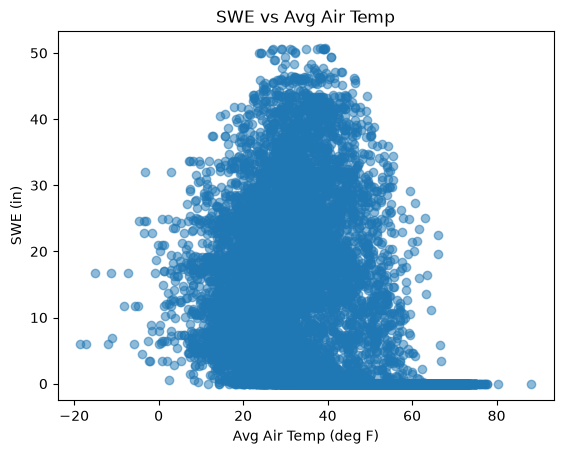

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt

plt.scatter(
    mores_data["Avg Air Temp (deg F)"],
    mores_data["SWE (in)"],
    alpha=0.5
)
plt.xlabel("Avg Air Temp (deg F)")
plt.ylabel("SWE (in)")
plt.title("SWE vs Avg Air Temp")
plt.show()


,Date,SWE (in),Snow Depth (in),Avg Air Temp (deg F),Avg Relative Humidity (%),Accumulated Precip (in)
0,1980-11-03,NaN,NaN,NaN,NaN,1.3
1,1980-11-04,NaN,NaN,NaN,NaN,NaN
2,1980-11-05,NaN,NaN,NaN,NaN,NaN
3,1980-11-06,NaN,NaN,NaN,NaN,NaN
4,1980-11-07,NaN,NaN,NaN,NaN,NaN
